# TF / IDF Normalization Comparison (UN / NT1 / NT2 / NI1) for Language Identification

This notebook builds on the **previous assignment** (IndicCorp v2 language identification
dataset + from-scratch TF-IDF vectorizer + from-scratch softmax logistic regression). It
reuses the same `train.csv` / `val.csv` / `test.csv` splits and implements the exact
TF / IDF formulas and the 6-model comparison specified on the board:

**TF variants**

$$TF_{UN}(t,d) = \ln(1+\text{tf}(t,d)) + 1 \qquad \text{(unnormalized — log-scaled raw count)}$$
$$TF_{NT_1}(t,d) = \frac{\text{tf}(t,d)}{\sum_{t'} \text{tf}(t',d)} \qquad \text{(normalized by total number of words in the sentence)}$$
$$TF_{NT_2}(t,d) = \frac{\text{tf}(t,d)}{\max_{t'} \text{tf}(t',d)} \qquad \text{(normalized by frequency of the most frequent word in the sentence)}$$

**IDF variants**

$$IDF_{UN}(t) = \ln\!\left(\frac{N}{n_t+1}\right) \qquad \text{(unnormalized)}$$
$$IDF_{NI_1}(t) = \ln\!\left(\frac{n_{t,\max}}{n_t+1}\right) \qquad \text{(normalized by the document frequency of the most frequent word across sentences)}$$

where $\text{tf}(t,d)$ is the raw count of term $t$ in sentence $d$, $n_t$ is the number of
training sentences containing $t$ (document frequency), $N$ is the total number of
training sentences, and $n_{t,\max} = \max_{t'} n_{t'}$ is the document frequency of the
single most frequent term in the training vocabulary.

**Six models** (TF x IDF combination), matching the assignment sheet's numbering:

| Model | TF     | IDF  |
|:-----:|:------:|:----:|
| 1     | UN     | UN   |
| 2     | NT1    | UN   |
| 3     | NT2    | UN   |
| 4     | UN     | NI1  |
| 5     | NT1    | NI1  |
| 6     | NT2    | NI1  |

As before, **no `sklearn` classes** are used for feature extraction, modeling, or
evaluation — `scipy.sparse` is used only as an efficient numeric container, and the
logistic regression / macro-F1 evaluation are implemented from scratch.

In [2]:
import re
import json
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import Counter

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Step 1: Load the dataset from the previous assignment

We reuse `train.csv`, `val.csv`, `test.csv`, and `label_map.json` produced by the
previous assignment's notebook. If you haven't run that notebook in this environment
yet, run it first (or copy those files next to this notebook) — this notebook does not
re-download or re-split the IndicCorp v2 data.

In [3]:
DATA_FILES = ["train.csv", "val.csv", "test.csv", "label_map.json"]
missing = [f for f in DATA_FILES if not __import__("os").path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"Missing files: {missing}. Please run the previous assignment's notebook "
        f"first (it saves train.csv / val.csv / test.csv / label_map.json into the "
        f"working directory), or copy those files here."
    )

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

with open("label_map.json", encoding="utf-8") as f:
    id2lang = {int(k): v for k, v in json.load(f).items()}
lang2id = {v: k for k, v in id2lang.items()}

n_classes = len(lang2id)
print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print("Number of languages:", n_classes)

y_train = train_df["language"].map(lang2id).to_numpy()
y_val = val_df["language"].map(lang2id).to_numpy()
y_test = test_df["language"].map(lang2id).to_numpy()

Train: (20493, 3)  Val: (2553, 3)  Test: (2576, 3)
Number of languages: 23


## Step 2: Feature extraction (recap)

We reuse the exact same feature space as the previous assignment: word unigrams +
bigrams (Unicode-aware `\w+` tokenizer), and character 2/3/4-grams with `#`-padded word
boundaries. Keeping the feature space identical across all 6 TF x IDF combinations makes
the comparison fair — only the *weighting formula* changes, not the vocabulary.

In [4]:
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def word_tokens(text):
    return TOKEN_RE.findall(text)

def word_ngrams(tokens, ngram_range=(1, 2)):
    feats = []
    lo, hi = ngram_range
    for n in range(lo, hi + 1):
        if n == 1:
            feats.extend(f"W1_{t}" for t in tokens)
        else:
            for i in range(len(tokens) - n + 1):
                feats.append(f"W{n}_" + "_".join(tokens[i:i + n]))
    return feats

def char_ngrams(text, sizes=(2, 3, 4)):
    feats = []
    for word in text.split():
        padded = f"#{word}#"
        for n in sizes:
            if len(padded) < n:
                continue
            for i in range(len(padded) - n + 1):
                feats.append(f"C{n}_" + padded[i:i + n])
    return feats

def extract_features(raw_text, lowercase=True, word_ngram_range=(1, 2), char_sizes=(2, 3, 4)):
    text = raw_text.lower() if lowercase else raw_text
    tokens = word_tokens(text)
    feats = word_ngrams(tokens, word_ngram_range)
    feats.extend(char_ngrams(text, char_sizes))
    return feats

## Step 3: Build the vocabulary and raw term-count matrices (shared across all 6 models)

We build the vocabulary **once**, from the training set only (`min_df` + `max_features`
pruning, same as the previous assignment), and compute the raw term-count matrix
$\text{tf}(t,d)$ for train/val/test **once**. Every one of the 6 models below is just a
different re-weighting of these same raw counts.

In [5]:
def build_vocabulary(corpus, min_df=2, max_features=60000):
    doc_freq = Counter()
    term_freq_total = Counter()
    tokenized_docs = []

    for doc in corpus:
        feats = extract_features(doc)
        tokenized_docs.append(feats)
        for f in set(feats):
            doc_freq[f] += 1
        term_freq_total.update(feats)

    candidate_terms = [t for t, df_ in doc_freq.items() if df_ >= min_df]
    if max_features is not None and len(candidate_terms) > max_features:
        candidate_terms = sorted(
            candidate_terms, key=lambda t: term_freq_total[t], reverse=True
        )[:max_features]
    candidate_terms = sorted(candidate_terms)

    vocabulary = {t: i for i, t in enumerate(candidate_terms)}
    doc_freq_array = np.array([doc_freq[t] for t in candidate_terms], dtype=np.float64)
    return vocabulary, doc_freq_array, tokenized_docs


def docs_to_count_matrix(tokenized_docs, vocabulary):
    n_docs = len(tokenized_docs)
    n_feats = len(vocabulary)
    rows, cols, data = [], [], []
    for r, feats in enumerate(tokenized_docs):
        counts = Counter(feats)
        for f, c in counts.items():
            col = vocabulary.get(f)
            if col is not None:
                rows.append(r)
                cols.append(col)
                data.append(c)
    return sp.csr_matrix((data, (rows, cols)), shape=(n_docs, n_feats), dtype=np.float64)

In [6]:
MIN_DF = 2
MAX_FEATURES = 60000

vocabulary, doc_freq_train, train_tokenized = build_vocabulary(
    train_df["text"].tolist(), min_df=MIN_DF, max_features=MAX_FEATURES
)

counts_train = docs_to_count_matrix(train_tokenized, vocabulary)
counts_val = docs_to_count_matrix(
    [extract_features(t) for t in val_df["text"].tolist()], vocabulary
)
counts_test = docs_to_count_matrix(
    [extract_features(t) for t in test_df["text"].tolist()], vocabulary
)

N_train = counts_train.shape[0]          # N in the IDF formulas
n_t_max = doc_freq_train.max()           # n_{t,max}: doc freq of the most frequent term

print("Vocabulary size:", len(vocabulary))
print("counts_train:", counts_train.shape)
print("counts_val:", counts_val.shape)
print("counts_test:", counts_test.shape)
print("N (train docs):", N_train)
print("n_t,max (max document frequency in train):", n_t_max)

Vocabulary size: 60000
counts_train: (20493, 60000)
counts_val: (2553, 60000)
counts_test: (2576, 60000)
N (train docs): 20493
n_t,max (max document frequency in train): 8108.0


## Step 4: TF formulas — UN, NT1, NT2

$$TF_{UN}(t,d) = \ln(1+\text{tf}(t,d)) + 1 \qquad \text{applied only to nonzero counts (sparsity-preserving, "sublinear" scaling)}$$
$$TF_{NT_1}(t,d) = \frac{\text{tf}(t,d)}{\sum_{t'} \text{tf}(t',d)}$$
$$TF_{NT_2}(t,d) = \frac{\text{tf}(t,d)}{\max_{t'} \text{tf}(t',d)}$$

$TF_{UN}$ is applied only to the stored (nonzero) entries of the sparse count matrix —
a term that doesn't appear in a sentence still contributes 0, not $\ln(1+0)+1=1$; this
matches how sublinear TF scaling is conventionally implemented and keeps the matrix
sparse.

In [7]:
def compute_tf(counts, mode):
    '''mode in {"UN", "NT1", "NT2"}'''
    if mode == "UN":
        tf = counts.tocsr(copy=True)
        tf.data = np.log1p(tf.data) + 1.0   # ln(1+tf) + 1, nonzero entries only
        return tf

    if mode == "NT1":
        row_sums = np.asarray(counts.sum(axis=1)).ravel()
        row_sums[row_sums == 0] = 1.0
        inv = sp.diags(1.0 / row_sums)
        return sp.csr_matrix(inv.dot(counts))

    if mode == "NT2":
        row_max = np.asarray(counts.max(axis=1).todense()).ravel()
        row_max[row_max == 0] = 1.0
        inv = sp.diags(1.0 / row_max)
        return sp.csr_matrix(inv.dot(counts))

    raise ValueError(f"Unknown TF mode: {mode}")

## Step 5: IDF formulas — UN, NI1

$$IDF_{UN}(t) = \ln\!\left(\frac{N}{n_t+1}\right)$$
$$IDF_{NI_1}(t) = \ln\!\left(\frac{n_{t,\max}}{n_t+1}\right)$$

Both are computed **once, from the training set only** ($N$, $n_t$, and $n_{t,\max}$ all
come from `counts_train`), and reused unchanged when weighting the validation/test
matrices, to avoid data leakage. The $+1$ in the denominator keeps the formula defined
and (per the board's "$\neq 0$" note) makes it very unlikely to land exactly on zero,
though values can go slightly negative for terms that appear in almost every sentence —
this is expected: it pushes near-ubiquitous, uninformative terms toward (or slightly
past) zero weight.

In [9]:
def compute_idf(doc_freq, N, n_t_max, mode):
    '''mode in {"UN", "NI1"}'''
    if mode == "UN":
        return np.log(N / (doc_freq + 1.0))
    if mode == "NI1":
        return np.log(n_t_max / (doc_freq + 1.0))
    raise ValueError(f"Unknown IDF mode: {mode}")


idf_UN = compute_idf(doc_freq_train, N_train, n_t_max, "UN")
idf_NI1 = compute_idf(doc_freq_train, N_train, n_t_max, "NI1")

print("idf_UN  : min={:.4f} max={:.4f} mean={:.4f}".format(idf_UN.min(), idf_UN.max(), idf_UN.mean()))
print("idf_NI1 : min={:.4f} max={:.4f} mean={:.4f}".format(idf_NI1.min(), idf_NI1.max(), idf_NI1.mean()))

idf_UN  : min=0.9271 max=8.8292 mean=6.3985
idf_NI1 : min=-0.0001 max=7.9020 mean=5.4713


## Step 6: Combine TF and IDF, then L2-normalize

$$\text{TFIDF}(t,d) = TF(t,d) \times IDF(t)$$

followed by L2 row-normalization (a standard finishing step applied identically to all 6
models, so the comparison isolates the TF/IDF formula, not row-scale effects), giving
the final feature vector fed into logistic regression.

In [10]:
def build_tfidf_matrix(counts, tf_mode, idf_vector):
    tf = compute_tf(counts, tf_mode)
    weighted = sp.csr_matrix(tf.multiply(idf_vector))

    norms = np.sqrt(weighted.multiply(weighted).sum(axis=1)).A1
    norms[norms == 0] = 1.0
    inv_norms = sp.diags(1.0 / norms)
    return sp.csr_matrix(inv_norms.dot(weighted))

## Step 7: Custom multinomial logistic regression + macro-F1 (recap)

Same from-scratch implementation as the previous assignment: softmax regression trained
by mini-batch gradient descent with L2 regularization, and a hand-built macro-F1 /
confusion-matrix evaluation. No `sklearn` classes.

In [11]:
class SoftmaxLogisticRegression:
    def __init__(self, n_features, n_classes, lr=0.5, reg_lambda=1e-4,
                 batch_size=256, epochs=30, seed=42, verbose=False):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lr = lr
        self.reg_lambda = reg_lambda
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose

        rng = np.random.RandomState(seed)
        self.W = rng.normal(0, 0.01, size=(n_features, n_classes))
        self.b = np.zeros(n_classes)

        self.train_loss_history_ = []
        self.val_metric_history_ = []

    @staticmethod
    def _softmax(Z):
        Z = Z - Z.max(axis=1, keepdims=True)
        expZ = np.exp(Z)
        return expZ / expZ.sum(axis=1, keepdims=True)

    def _forward(self, X):
        Z = X.dot(self.W) + self.b
        return self._softmax(Z)

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def _one_hot(self, y):
        n = len(y)
        Y = np.zeros((n, self.n_classes))
        Y[np.arange(n), y] = 1.0
        return Y

    def _cross_entropy(self, P, Y):
        eps = 1e-12
        return -np.mean(np.sum(Y * np.log(P + eps), axis=1))

    def fit(self, X, y, X_val=None, y_val=None, eval_fn=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        for epoch in range(1, self.epochs + 1):
            np.random.shuffle(indices)
            epoch_losses = []

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                Y_batch = self._one_hot(y_batch)

                P = self._forward(X_batch)
                loss = self._cross_entropy(P, Y_batch) + \
                    0.5 * self.reg_lambda * np.sum(self.W ** 2)
                epoch_losses.append(loss)

                grad_logits = (P - Y_batch) / X_batch.shape[0]
                grad_W = X_batch.T.dot(grad_logits) + self.reg_lambda * self.W
                grad_b = grad_logits.sum(axis=0)

                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            mean_loss = float(np.mean(epoch_losses))
            self.train_loss_history_.append(mean_loss)

            if X_val is not None and y_val is not None and eval_fn is not None:
                val_score = eval_fn(y_val, self.predict(X_val))
                self.val_metric_history_.append(val_score)

            if self.verbose:
                msg = f"Epoch {epoch:02d}/{self.epochs} - train_loss: {mean_loss:.4f}"
                if self.val_metric_history_:
                    msg += f" - val_macroF1: {self.val_metric_history_[-1]:.4f}"
                print(msg)

        return self

In [12]:
def confusion_matrix_custom(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1_per_class(cm):
    n_classes = cm.shape[0]
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c] = (2 * precision[c] * recall[c] / (precision[c] + recall[c])
                 if (precision[c] + recall[c]) > 0 else 0.0)

    return precision, recall, f1


def macro_f1_score(y_true, y_pred, n_classes):
    cm = confusion_matrix_custom(y_true, y_pred, n_classes)
    _, _, f1 = precision_recall_f1_per_class(cm)
    return float(np.mean(f1))


def accuracy_score_custom(y_true, y_pred):
    return float(np.mean(np.array(y_true) == np.array(y_pred)))

## Step 8: Train and evaluate all 6 models

Model numbering matches the assignment sheet exactly:

| Model | TF     | IDF  |
|:-----:|:------:|:----:|
| 1     | UN     | UN   |
| 2     | NT1    | UN   |
| 3     | NT2    | UN   |
| 4     | UN     | NI1  |
| 5     | NT1    | NI1  |
| 6     | NT2    | NI1  |

Model 1 (`TF=UN, IDF=UN`) is the fully unnormalized baseline; models 2–6 introduce TF
and/or IDF normalization.

In [13]:
MODEL_DEFINITIONS = [
    (1, "UN",  "UN"),
    (2, "NT1", "UN"),
    (3, "NT2", "UN"),
    (4, "UN",  "NI1"),
    (5, "NT1", "NI1"),
    (6, "NT2", "NI1"),
]

idf_vectors = {"UN": idf_UN, "NI1": idf_NI1}

EPOCHS = 25
results = []
trained_models = {}

for model_no, tf_mode, idf_mode in MODEL_DEFINITIONS:
    combo_name = f"Model {model_no}: TF={tf_mode}, IDF={idf_mode}"
    print("=" * 70)
    print(combo_name)
    print("=" * 70)

    idf_vec = idf_vectors[idf_mode]
    X_train = build_tfidf_matrix(counts_train, tf_mode, idf_vec)
    X_val = build_tfidf_matrix(counts_val, tf_mode, idf_vec)
    X_test = build_tfidf_matrix(counts_test, tf_mode, idf_vec)

    model = SoftmaxLogisticRegression(
        n_features=X_train.shape[1],
        n_classes=n_classes,
        lr=0.5,
        reg_lambda=1e-4,
        batch_size=256,
        epochs=EPOCHS,
        seed=RANDOM_SEED,
        verbose=False,
    )
    macro_f1_fn = lambda yt, yp: macro_f1_score(yt, yp, n_classes)
    model.fit(X_train, y_train, X_val=X_val, y_val=y_val, eval_fn=macro_f1_fn)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_macro_f1 = macro_f1_score(y_val, val_pred, n_classes)
    val_acc = accuracy_score_custom(y_val, val_pred)
    test_macro_f1 = macro_f1_score(y_test, test_pred, n_classes)
    test_acc = accuracy_score_custom(y_test, test_pred)

    print(f"val_macro_f1={val_macro_f1:.4f}  val_acc={val_acc:.4f}  "
          f"test_macro_f1={test_macro_f1:.4f}  test_acc={test_acc:.4f}")

    results.append({
        "model": model_no,
        "tf_mode": tf_mode,
        "idf_mode": idf_mode,
        "combination": combo_name,
        "val_macro_f1": val_macro_f1,
        "val_accuracy": val_acc,
        "test_macro_f1": test_macro_f1,
        "test_accuracy": test_acc,
    })
    trained_models[model_no] = model

results_df = pd.DataFrame(results)
results_df

Model 1: TF=UN, IDF=UN
val_macro_f1=0.9547  val_acc=0.9553  test_macro_f1=0.9469  test_acc=0.9472
Model 2: TF=NT1, IDF=UN
val_macro_f1=0.9538  val_acc=0.9546  test_macro_f1=0.9454  test_acc=0.9464
Model 3: TF=NT2, IDF=UN
val_macro_f1=0.9542  val_acc=0.9550  test_macro_f1=0.9470  test_acc=0.9476
Model 4: TF=UN, IDF=NI1
val_macro_f1=0.9562  val_acc=0.9569  test_macro_f1=0.9488  test_acc=0.9491
Model 5: TF=NT1, IDF=NI1
val_macro_f1=0.9478  val_acc=0.9503  test_macro_f1=0.9420  test_acc=0.9449
Model 6: TF=NT2, IDF=NI1
val_macro_f1=0.9544  val_acc=0.9550  test_macro_f1=0.9480  test_acc=0.9484


,model,tf_mode,idf_mode,combination,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
0,1,UN,UN,"Model 1: TF=UN, IDF=UN",0.954716,0.955347,0.946941,0.947205
1,2,NT1,UN,"Model 2: TF=NT1, IDF=UN",0.953760,0.954563,0.945430,0.946429
2,3,NT2,UN,"Model 3: TF=NT2, IDF=UN",0.954175,0.954955,0.946974,0.947593
3,4,UN,NI1,"Model 4: TF=UN, IDF=NI1",0.956228,0.956913,0.948798,0.949146
4,5,NT1,NI1,"Model 5: TF=NT1, IDF=NI1",0.947761,0.950255,0.942027,0.944876
5,6,NT2,NI1,"Model 6: TF=NT2, IDF=NI1",0.954377,0.954955,0.948000,0.948370


In [14]:
results_df_sorted = results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
print("Ranked by test macro-F1 (best first):")
results_df_sorted

Ranked by test macro-F1 (best first):


,model,tf_mode,idf_mode,combination,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
0,4,UN,NI1,"Model 4: TF=UN, IDF=NI1",0.956228,0.956913,0.948798,0.949146
1,6,NT2,NI1,"Model 6: TF=NT2, IDF=NI1",0.954377,0.954955,0.948000,0.948370
2,3,NT2,UN,"Model 3: TF=NT2, IDF=UN",0.954175,0.954955,0.946974,0.947593
3,1,UN,UN,"Model 1: TF=UN, IDF=UN",0.954716,0.955347,0.946941,0.947205
4,2,NT1,UN,"Model 2: TF=NT1, IDF=UN",0.953760,0.954563,0.945430,0.946429
5,5,NT1,NI1,"Model 5: TF=NT1, IDF=NI1",0.947761,0.950255,0.942027,0.944876


## Step 9: Visual comparison

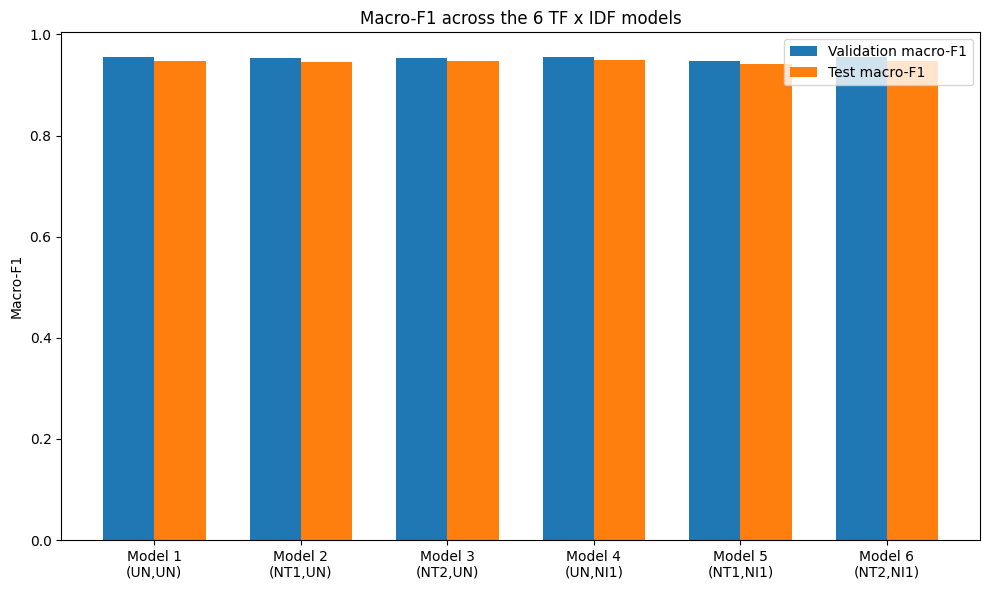

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width / 2, results_df["val_macro_f1"], width, label="Validation macro-F1")
ax.bar(x + width / 2, results_df["test_macro_f1"], width, label="Test macro-F1")

ax.set_xticks(x)
ax.set_xticklabels([f"Model {m}\n({t},{i})" for m, t, i in
                     zip(results_df["model"], results_df["tf_mode"], results_df["idf_mode"])])
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 across the 6 TF x IDF models")
ax.legend()
fig.tight_layout()
plt.show()

## Step 10: Save results

In [16]:
results_df.to_csv("tf_idf_normalization_comparison_UN_NT_NI.csv", index=False)

best_row = results_df_sorted.iloc[0]
print(f"Best model on test macro-F1: Model {best_row['model']} "
      f"(TF={best_row['tf_mode']}, IDF={best_row['idf_mode']}, "
      f"test_macro_f1={best_row['test_macro_f1']:.4f})")

best_model_no = int(best_row["model"])
best_tf, best_idf = best_row["tf_mode"], best_row["idf_mode"]
best_model = trained_models[best_model_no]

with open("best_tfidf_model.pkl", "wb") as f:
    pickle.dump({
        "W": best_model.W,
        "b": best_model.b,
        "model_number": best_model_no,
        "tf_mode": best_tf,
        "idf_mode": best_idf,
        "vocabulary": vocabulary,
        "idf_vector": idf_vectors[best_idf],
        "lang2id": lang2id,
        "id2lang": id2lang,
    }, f)

print("Saved: tf_idf_normalization_comparison_UN_NT_NI.csv, best_tfidf_model.pkl")

Best model on test macro-F1: Model 4 (TF=UN, IDF=NI1, test_macro_f1=0.9488)
Saved: tf_idf_normalization_comparison_UN_NT_NI.csv, best_tfidf_model.pkl


## Notes / how to interpret the comparison

- **Model 1** (`TF=UN, IDF=UN`) is the fully unnormalized baseline (both formulas as
  given on the board — note $TF_{UN}$ here is the log-scaled $\ln(1+\text{tf})+1$ form,
  not a plain raw count).
- **NT1** (total-words TF normalization) tends to help most when sentence lengths vary a
  lot, since it prevents longer sentences from dominating purely because they contain
  more tokens.
- **NT2** (max-frequency TF normalization) rescales every sentence so its most frequent
  term has weight 1; this can help when a handful of high-frequency terms dominate raw
  counts, but can also over-emphasize sentences with one very repetitive term.
- **NI1** (max-document-frequency IDF normalization) scales every term's IDF relative to
  the document frequency of the single most common term in the training vocabulary,
  rather than the total corpus size $N$ — this behaves differently from $IDF_{UN}$
  especially for very frequent script-marking character n-grams.
- Compare `val_macro_f1` and `test_macro_f1` together: a model that scores well on
  validation but not on test is a sign of instability, not real improvement.
- All 6 models were trained with the **same vocabulary, hyperparameters, random seed,
  and number of epochs** — the only variable being compared is the TF/IDF formula.